In [1]:
import math
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import torch

In [3]:
#define used constants
miu_eff = 100 # cm2/V*s
C_ox = 3.45e-5  # 10nm thickness of SiOx  F/cm2
W = 1 # um
L = 1 # um
Vt = 0.7 # V
m = 1.1
k = 1.38e-23 # J/K
T = 300 # K
q = 1.6e-19 # C
Vds = 0.1 # V
bias= 2.26e-07  # A

In [4]:
q_T=k*T/q

def Ids_Vgs(Vgs):
    
    
    if Vgs >= Vt:
        #linear zone
        Ids = miu_eff*C_ox*(W/L)*(Vgs-Vt)*Vds+bias  #适用于 Vgs>Vt
        
    #elif Vgs > Vt and Vgs <= 0.8:
        #transition zone
        #n = [((Vgs-Vt)/0.1)]
        #Ids = (1-n)*miu_eff*C_ox*(W/L)*(m-1.0)*pow(q_T,2)*math.exp((Vgs-Vt)/(m*q_T))*(1.0-math.exp(-Vds/q_T))+n*(miu_eff*C_ox*(W/L)*(Vgs-Vt)*Vds+bias)
        
    elif Vgs <= Vt:
        #subthreshold zone
        Ids = miu_eff*C_ox*(W/L)*(m-1.0)*pow(q_T,2)*math.exp((Vgs-Vt)/(m*q_T))*(1.0-math.exp(-Vds/q_T))  #适用于 Vgs<=Vt
    
    return Ids


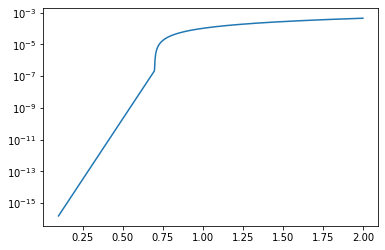

In [5]:
#展示模型的IV曲线
Vgs = list(np.linspace(0.1,2,1001))
Ids= []
for num in Vgs:
    Ids.append(Ids_Vgs(num))
plt.plot(Vgs,Ids)
plt.yscale('log')

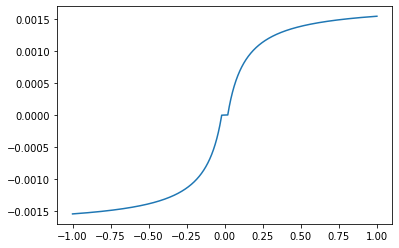

In [38]:
Gref = 1 #设置参考电导是1
GA = np.linspace(1,21,1001)

Vread = 1.2
Vgs_divide = Vread*(GA/(Gref+GA))  #分压
Binary_dict={}

Ids_neg=Ids_Vgs(Vread/2)

#K取20
for K in [20]:

    GH = (GA-Gref)/K
    Ids=[]

    for Vgs in list(Vgs_divide):
        Ids.append(Ids_Vgs(Vgs)-Ids_neg)

    GH_ = (-GH)[::-1]
    Ids_ = list(-np.array(Ids))[::-1]

    GH = np.append(GH_,GH)
    Ids = Ids_+Ids
    GB = np.array(Ids)/Vds 
    
    Binary_dict['GH_'+str(K)]=GH
    Binary_dict['GB_'+str(K)]=GB

    plt.plot(GH,GB)
    plt.yscale('linear')
    
#pd.DataFrame(Binary_dict).to_csv(r'C:\Users\13170\AAA_BNN_CL\BNN_CL_simulation\results\T-E_model_prediction'
                                 #+'\\'+'device_model_binary_subthreshold_Vread=1.2.csv')

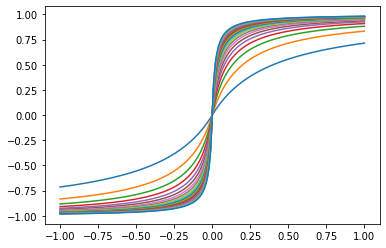

In [7]:
def device_Binarize(tensor,K):
    #根据器件特性输出二值化特点
    temp=torch.zeros_like(tensor)
    temp[tensor>=0.0]=2.0*((K*tensor[tensor>=0.0]+1)/(K*tensor[tensor>=0.0]+2)-0.5)
    temp[tensor<0.0]=-2.0*((-K*tensor[tensor<0.0]+1)/(-K*tensor[tensor<0.0]+2)-0.5)

    return temp

Wh_input=torch.linspace(-1,1,201)
Wh_Wb={}

for K in np.linspace(5,105,21):

    Wh_Wb['Wh_'+str(K)]=Wh_input
    Wh_Wb['Wb_'+str(K)]=device_Binarize(Wh_input,K)
    
    plt.plot(Wh_input,device_Binarize(Wh_input,K))
    plt.yscale('linear')
    
pd.DataFrame(Wh_Wb).to_csv(r'C:\Users\13170\Germany_project_simulation\Germany_CL\results'+'\\'+'Wh_Wb_data.csv')

(1001,)
(1001,)
(1001,)
(1001,)
(1001,)


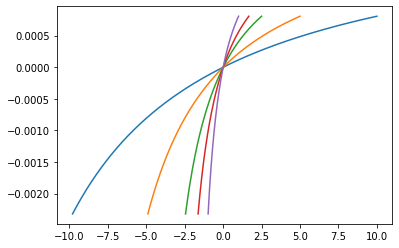

In [35]:
# define a new model in which GA keeps the same
Gref = 50 #设置参考电导是50
GA = np.linspace(1,100,1001)
Vread = 1.4
Vgs_divide_pos = Vread*(GA/(Gref+GA))  #正权重分压
Vgs_divide_neg = Vread*(Gref/(Gref+GA)) #负权重分压

K=50  #量化因子
Binary_dict={}

for K in [5,10,20,30,50]:

    GH = (GA-Gref)/K


    Ids=[]

    for Vgs_pos,Vgs_neg in zip(list(Vgs_divide_pos),list(Vgs_divide_neg)):
        
        Ids_pos = Ids_Vgs(Vgs_pos)
        Ids_neg = Ids_Vgs(Vgs_neg)
        Ids.append(Ids_pos-Ids_neg)  #求得Ids的值

    
    GB = np.array(Ids)/Vds 
    print(GB.shape)
    Binary_dict['GH_'+str(K)]=GH
    Binary_dict['GB_'+str(K)]=GB

    plt.plot(GH,GB)
    plt.yscale('linear')
    
pd.DataFrame(Binary_dict).to_csv(r'C:\Users\13170\Germany_project_simulation\Germany_CL\results'+'\\'+'device_model_binary_non_symmetry.csv')

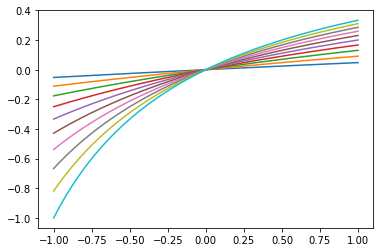

In [47]:
def device_Binarize_non_symmetry(tensor,K):
    #根据器件特性输出二值化特点
    temp=torch.zeros_like(tensor)
    temp=(K*tensor)/(K*tensor+100)

    return temp

Wh_input=torch.linspace(-1,1,201)
Wh_Wb={}

for K in np.linspace(5,50,10):
    Wh_Wb['Wh_'+str(K)]=Wh_input
    Wh_Wb['Wb_'+str(K)]=device_Binarize_non_symmetry(Wh_input,K)
    
    plt.plot(Wh_input,device_Binarize_non_symmetry(Wh_input,K))
    plt.yscale('linear')
    
pd.DataFrame(Wh_Wb).to_csv(r'C:\Users\13170\Germany_project_simulation\Germany_CL\results'+'\\'+'Wh_Wb_data_non_symmetry.csv')

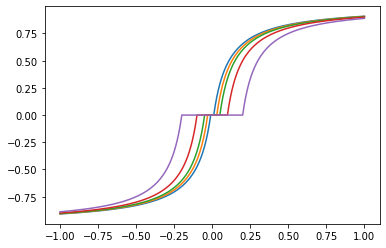

In [56]:
def device_Binarize_sub_th(tensor,bound):
    #器件部分区域处于亚阈值区，部分区间变化很小，几乎一直为零
    
    temp=torch.zeros_like(tensor)
    
    #bound=0.05  #一直为零的区间边界范围 
    
    #temp[tensor.abs() <= bound ] = 0.0
    temp[tensor>bound]=2.0*((20*(tensor[tensor>bound] - bound)+1)/(20*(tensor[tensor>bound] - bound)+2)-0.5)
    temp[tensor<(bound*-1)]=-2.0*((-20*( tensor[tensor<(bound*-1)] + bound )+1)/(-20*( tensor[tensor<(bound*-1)] + bound )+2)-0.5) 
    
    
    return temp

Wh_input=torch.linspace(-1,1,201)
Wh_Wb={}

for bound in [0.01,0.03,0.05,0.1,0.2]:
    Wh_Wb['Wh_'+str(bound)]=Wh_input
    Wh_Wb['Wb_'+str(bound)]=device_Binarize_sub_th(Wh_input,bound)
    
    plt.plot(Wh_input,device_Binarize_sub_th(Wh_input,bound))
    plt.yscale('linear')
    
pd.DataFrame(Wh_Wb).to_csv(r'C:\Users\13170\AAA_BNN_CL\BNN_CL_simulation\results\T-E_model_prediction'+'\\'+'Wh_Wb_data_sub_threshold.csv')